# Informe Técnico: Sistema de Recuperación de Información

**Ivonne Ayala - David Morales**  
**Recuperación de Información**  
**01 de junio de 2026**

## 1. Descripción del Corpus

Se utilizó el dataset **Reuters "Uncovering Financial Insights with the Reuters 2"** de Kaggle (`ModApte_train.csv`), que contiene **9,603 documentos de noticias financieras** de la agencia Reuters cubriendo mercados de commodities, política monetaria, ganancias corporativas y comercio internacional.

Para cada documento se concatenan los campos `title` y `text` como entrada al sistema. La columna `topics` lista las categorías asignadas editorialmente a cada noticia (p.ej. *earn*, *acq*, *crude*, *cocoa*, *interest*) y se usa como ground truth para construir los qrels de evaluación.

La distribución de topics es muy desigual: `earn` concentra casi 2,877 documentos (casi un tercio del corpus), mientras que topics como `cocoa` tienen apenas 55. Esta asimetría explica directamente por qué el recall global es bajo incluso con modelos que funcionan bien, como se discute en la sección 3.

## 2. Arquitectura del Sistema

### 2.1 Estructura del proyecto

```
proyecto/
├── models/
│   ├── base.py          # Clase abstracta RetrievalModel
│   ├── jaccard.py       # Similitud Jaccard
│   ├── tfidf.py         # TF-IDF con coseno
│   ├── bm25.py          # BM25 (Okapi)
│   └── semantic.py      # Embeddings + FAISS
├── preprocessing.py     # Pipeline de texto + caché + índice invertido
├── evaluation.py        # Evaluación batch sobre qrels
├── metrics.py           # P@K, R@K, AP, MAP (implementación propia)
├── qrels.py             # Extracción de qrels desde topics de Reuters
└── main.py              # CLI interactiva con Rich
```

Todos los modelos heredan de `RetrievalModel`, una clase abstracta con `@abstractmethod search()`. Esto garantiza que la CLI y el módulo de evaluación puedan ejecutarlos de forma uniforme — agregar un nuevo modelo no requiere tocar el loop principal ni el evaluador.

### 2.2 Preprocesamiento (`preprocessing.py`)

El pipeline de normalización aplica cuatro pasos en orden:

1. **Limpieza regex** — elimina todo carácter no alfabético (`[^a-z\s]`)
2. **Tokenización** — NLTK `word_tokenize`
3. **Remoción de stopwords** — lista estándar de inglés (NLTK)
4. **Stemming** — `SnowballStemmer('english')`

Se eligió Snowball sobre Porter porque maneja mejor variantes morfológicas del inglés financiero (*earnings → earn*, *acquired → acquir*). No se aplicó lematización porque el stemming es más rápido y la diferencia en precisión es marginal para este dominio.

`load_or_build()` implementa caché con `joblib`: la primera ejecución procesa el corpus y serializa el DataFrame y el índice en `cache/`. Las siguientes cargan desde disco, reduciendo el arranque de ~40 segundos a menos de 2.

### 2.3 Índice Invertido

Estructura: `{término: {doc_id: frecuencia_bruta}}`, construida con `defaultdict` y `Counter`. Los tres modelos clásicos operan directamente sobre este índice sin librerías de IR externas. Se almacena frecuencia bruta (no normalizada) porque cada modelo aplica su propia función de peso sobre ella.

### 2.4 Modelos de Recuperación

#### Jaccard (`JaccardModel`)

$$Jaccard(Q, D) = \frac{|Q \cap D|}{|Q \cup D|}$$

Modelo binario: solo importa si el término está presente, no cuántas veces aparece. Se precomputa la cardinalidad del vocabulario de cada documento en `__init__` para no recalcularla por query. La unión se obtiene como `|Q| + |D| - |Q ∩ D|`, evitando materializar el conjunto completo.

**Limitación estructural:** al crecer `|Q|`, el denominador crece y los scores caen aunque los documentos sean relevantes — las queries largas penalizan a Jaccard por diseño.

#### TF-IDF Coseno (`TFIDFModel`)

Esquema de pesos **lnc.ltc** (notación SMART):

- **TF:** logarítmico → `1 + log(tf)`
- **IDF:** clásico → `log(N / df_t)`  
- **Normalización:** coseno → divide el producto punto por `‖doc‖ × ‖query‖`

Las normas de documentos se precomputan en `__init__` iterando sobre el índice invertido completo. Sin esta optimización, el modelo recalcularía O(|V|) operaciones por cada consulta.

#### BM25 (`BM25Model`)

$$score(D, Q) = \sum_{t \in Q} IDF(t) \cdot \frac{tf(t,D) \cdot (k_1 + 1)}{tf(t,D) + k_1 \cdot (1 - b + b \cdot \frac{|D|}{avgdl})}$$

Parámetros: k₁=1.5, b=0.75 (estándar de la literatura). La frecuencia de término satura — más repeticiones aportan cada vez menos al score — y documentos más largos que el promedio son penalizados. No requiere normalización coseno porque la longitud ya entra en la fórmula.

#### Semántico (`SemanticModel`)

Usa `all-MiniLM-L6-v2` de SentenceTransformers para generar embeddings de 384 dimensiones. Los vectores se normalizan con L2 y se indexan en un `IndexFlatIP` de FAISS; el inner product sobre vectores normalizados equivale a similitud coseno.

La query se pasa **sin preprocesar** — el modelo transformer opera sobre texto natural y el stemming degradaría la representación semántica. El índice FAISS se guarda en `faiss_index.bin` para evitar reencodeado (~2 minutos en CPU por cada ejecución).

## 3. Evaluación

### 3.1 Qrels

Se invierten los topics del CSV: si un documento tiene el topic `crude`, se considera relevante para la query `"crude"`. Se filtran topics con menos de 10 documentos para evitar que queries con 1-2 relevantes distorsionen el MAP. Resultado: **61 queries de evaluación**.

### 3.2 Métricas (implementación propia)

| Métrica | Definición |
|---------|----------|
| Precision@K | Proporción de relevantes en el top-K |
| Recall@K | Proporción del total de relevantes que aparecen en el top-K |
| Average Precision | Premia que los relevantes estén en posiciones altas del ranking |
| MAP | Promedio de AP sobre las 61 queries |

### 3.3 Resultados (k=10, 61 queries)

| Modelo | MAP | avg P@10 | avg R@10 |
|--------|-----|----------|----------|
| Jaccard | 0.0541 | 0.2246 | 0.0628 |
| TF-IDF Coseno | 0.0632 | 0.2557 | 0.0723 |
| BM25 | 0.0666 | 0.2525 | 0.0742 |
| Semántico | **0.0801** | **0.3115** | **0.0861** |

El orden Jaccard < TF-IDF < BM25 < Semántico es consistente con lo esperado. El recall global es bajo (~6-8%) no porque los modelos fallen, sino porque topics como `earn` tienen 2,877 documentos relevantes — recuperar 10 de ellos representa apenas el 0.35% del total relevante. Incrementar K mejoraría el recall pero degradaría la precisión.

## 4. Análisis Comparativo por Tipo de Consulta

Se eligieron cuatro queries que exhiben comportamientos cualitativamente distintos entre los modelos. Todos los resultados son reales, obtenidos ejecutando el sistema sobre el corpus completo de 9,603 documentos.

### Query 1: `"earn"` — Término único de alta frecuencia (baseline)

**Top-10 de cada modelo:**

| Rank | Jaccard | TF-IDF | BM25 | Semántico |
|------|---------|--------|------|-----------|
| 1 | WEYERHAEUSER SEES SIGNIFICANT INCREASE ✓ | UK AVERAGE EARNINGS ROSE 7.6 PCT ✓ | U.S. REAL EARNINGS ROSE 0.6 PCT ✓ | PETROLITE CORP SETS PAYOUT ✓ |
| 2 | UK AVERAGE EARNINGS ROSE 7.6 PCT ✓ | U.S. REAL EARNINGS ROSE 0.6 PCT ✓ | ARCO UP ON HIGHER EARNINGS ESTIMATE ✓ | PEOPLES BANCORPORATION QUARTERLY DIV. ✓ |
| 3 | BANK OF BOSTON EXPECTS 1ST QTR EARNINGS ✓ | WEYERHAEUSER SEES SIGNIFICANT INCREASE ✓ | KINDER-CARE SEES HIGHER EARNINGS ✓ | MONY REAL ESTATE INVESTORS 3RD QTR ✓ |
| 4 | LABOR DEPT REPORTS U.S. REAL EARNINGS ✓ | COMPUTER MICROFILM SEES HIGHER 1987 ✓ | CHELSEA SEES LOWER 2ND QTR NET ✓ | METALLGESELLSCHAFT AG ✓ |
| 5 | REGENCY CRUISES CORRECTS EARNINGS ✓ | BANK OF BOSTON EXPECTS 1ST QTR ✓ | SOFTWARE AG SEES WEAK RESULTS ✓ | GENERAL CINEMA CLASS B DIVIDEND ✓ |


| Métrica | Jaccard | TF-IDF | BM25 | Semántico |
|---------|---------|--------|------|-----------|
| P@10 | 0.8000 | 0.8000 | **0.9000** | **1.0000** |
| R@10 | 0.0028 | 0.0028 | 0.0031 | 0.0035 |
| AP   | 0.0021 | 0.0018 | 0.0025 | 0.0035 |

Con un solo término sin ambigüedad, los cuatro modelos se comportan de forma parecida. Lo más notable está en el ranking semántico: los primeros resultados son anuncios de dividendos (PETROLITE SETS PAYOUT, PEOPLES BANCORPORATION QUARTERLY DIVIDEND). Esto no es un error — el topic `earn` en Reuters incluye noticias de pagos a accionistas, y el modelo captura esa asociación sin que la palabra "earn" aparezca explícitamente en los documentos. Los modelos léxicos no pueden hacer eso.


### Query 2: `"fed raises interest rates"` — TF-IDF falla, BM25 y semántico destacan

Esta es la query que mejor ilustra las diferencias entre modelos. No tiene qrels directos (no hay un topic llamado "interest rates"), por lo que la evaluación es cualitativa.

**Jaccard — top-5:**

| Rank | Título | Score |
|------|--------|-------|
| 1 | FED'S JOHNSON SAYS HE DOES NOT SEE INCREASING RATES | 0.3000 |
| 2 | COMERICA RAISES PRIME RATE | 0.2308 |
| 3 | CITIBANK SAYS IT RAISES BASE RATE TO 7-3/4 PCT | 0.2222 |
| 4 | CONTINENTAL ILLINOIS RAISES PRIME RATE | 0.1818 |
| 5 | VOLCKER SAYS FED POLICY NOT RESPONSIBLE FOR PESO... | 0.1818 |

**TF-IDF — top-5:**

| Rank | Título | Score |
|------|--------|-------|
| 1 | FED SETS 1.5 BILLION DLR CUSTOMER REPURCHASE | 0.4743 |
| 2 | FED SETS 1.5 BILLION DLR CUSTOMER REPURCHASE | 0.4743 |
| 3 | FED SETS 1.5 BILLION DLR CUSTOMER REPURCHASE | 0.4743 |
| 4 | FED SETS 2.5 BILLION DLR CUSTOMER REPURCHASE | 0.4743 |
| 5 | FED BUYING ONE BILLION DLRS OF BILLS FOR CUSTOMERS | 0.4684 |

**BM25 — top-5:**

| Rank | Título | Score |
|------|--------|-------|
| 1 | ANALYSTS SEE SLOW MOVE TO HIGHER U.S. PRIME RATE | 13.7899 |
| 2 | VOLCKER SAYS FED POLICY NOT LINKED TO RATE RISE | 13.4333 |
| 3 | FED'S JOHNSON SAYS HE DOES NOT SEE INCREASING RATES | 13.3606 |
| 4 | U.S. CREDIT MARKET OUTLOOK - PRIME RATE | 12.2879 |
| 5 | U.S. INTERVENED TO AID DLR IN JANUARY, FED SAYS | 12.1782 |

**Semántico — top-5:**

| Rank | Título | Score |
|------|--------|-------|
| 1 | WHITE HOUSE SAYS INTEREST RATES REFLECT MARKET... | 0.6206 |
| 2 | FED'S POLICY EASE MAY END WITH 2ND QTR RATE CHANGE | 0.6138 |
| 3 | ANALYSTS SEE SLOW MOVE TO HIGHER U.S. PRIME RATE | 0.5770 |
| 4 | U.S. CREDIT MARKET OUTLOOK - PRIME RATE | 0.5722 |
| 5 | FED'S JOHNSON SAYS HE DOES NOT SEE INCREASING RATES | 0.5593 |

TF-IDF devuelve los 10 primeros resultados como variantes del mismo tipo de documento: boletines de operaciones de mercado abierto del Fed ("FED SETS X BILLION DLR CUSTOMER REPURCHASE"). El término "fed" es muy frecuente en el corpus y domina el vector de la query, arrastrando documentos que lo mencionan muchas veces en textos cortos, independientemente de que hablen de tasas de interés. TF-IDF no penaliza la longitud del documento.

BM25 corrige esto directamente, la saturación de TF evita que boletines con "fed" repetido escalen injustamente, y la normalización por longitud penaliza esos textos cortos. Sus resultados son notoriamente más útiles.

El modelo semántico va un paso más allá recuperando "WHITE HOUSE SAYS INTEREST RATES REFLECT MARKET" — un documento cuya intención encaja con la query aunque probablemente no contenga "fed" ni "raises" en esos términos exactos.


### Query 3: `"cocoa beans chocolate"` — Ruido léxico y falsos positivos en BM25

El topic `cocoa` tiene 55 documentos relevantes. Esta query combina términos directos del dominio ("cocoa", "beans") con uno relacionado ("chocolate").

| Rank | Jaccard | TF-IDF | BM25 | Semántico |
|------|---------|--------|------|-----------|
| 1 | DUTCH COCOA BEAN IMPORTS RISE IN JANUARY ✓ | DUTCH COCOA BEAN IMPORTS RISE IN JANUARY ✓ | DUTCH COCOA BEAN IMPORTS RISE IN JANUARY ✓ | BAHIA COCOA REVIEW ✓ |
| 2 | Cocoa Council agrees new buffer stock rules ✓ | JAPAN DENIES PLANS TO CUT DUTIES ON CHOCOLATE ✓ | COCOA DEAL SEEN POSITIVE ✓ | DUTCH COCOA BEAN IMPORTS ✓ |
| 3 | ICCO PUTS 1986/87 WORLD COCOA SURPLUS ✓ | U.S. 1987 CORN, SOYBEAN ACREAGE ESTIMATES ✗ | TRADERS CUT BAHIA TEMPORAO COCOA CROP ✓ | PESSIMISM MOUNTS OVER BAHIAN TEMPORAO COCOA ✓ |
| 4 | GHANA COCOA PURCHASES 1,323 TONNES ✓ | COCOA BUFFER STOCK RULES EFFECTIVE ✓ | INDONESIAN TEA, COCOA EXPORTS SEEN UP ✓ | JACOBS SUCHARD SEES 100,000 TONNE COCOA ✓ |
| 9 | — | — | **CAROLYN BEAN COMPLETES ACQUISITION ✗** | — |
| 10 | — | — | **JAPAN BUYS LARGE AMOUNT OF BRAZILIAN SOYBEANS ✗** | — |

| Métrica | Jaccard | TF-IDF | BM25 | Semántico |
|---------|---------|--------|------|-----------|
| P@10 | **0.9000** | 0.8000 | 0.8000 | **0.9000** |
| R@10 | 0.1636 | 0.1455 | 0.1455 | 0.1636 |
| AP   | 0.1549 | 0.1274 | 0.1455 | 0.1519 |

BM25 introduce dos falsos positivos llamativos: "CAROLYN BEAN COMPLETES ACQUISITION" (el apellido *Bean* matcheó el término de la query) y "JAPAN BUYS LARGE AMOUNT OF BRAZILIAN SOYBEANS" (el stem de *soybean* incluye *bean*). La ponderación BM25 eleva estos documentos cortos donde el término "beans" aparece con peso alto. Jaccard los evita naturalmente porque `|Q ∩ D| / |Q ∪ D|` es bajo cuando el documento tiene muchos términos no relacionados. El modelo semántico tampoco los recupera — entiende que "CAROLYN BEAN" no es sobre cacao.


### Query 4: `"crude oil"` — Diferencias en diversidad temática del ranking

El topic `crude` tiene 389 documentos relevantes. Query de dos términos frecuentes sin ambigüedad.

| Rank | Jaccard | TF-IDF | BM25 | Semántico |
|------|---------|--------|------|-----------|
| 1 | CONOCO RAISES CRUDE OIL PRICES ✓ | SHELL CANADA CUTS CRUDE OIL PRICES ✓ | DIAMOND SHAMROCK RAISES CRUDE OIL ✓ | API SAYS U.S. CRUDE OIL OUTPUT OFF ✓ |
| 2 | MURPHY RAISES CRUDE OIL POSTED PRICES ✓ | CONOCO RAISES CRUDE OIL PRICES ✓ | SHELL CANADA RAISED CRUDE OIL ✓ | RECENT U.S. OIL DEMAND UP 1.9 PCT ✓ |
| 3 | SHELL CANADA CUTS CRUDE OIL PRICES ✓ | SHELL CANADA RAISED CRUDE OIL ✓ | IMPERIAL OIL IN TALKS WITH SUPPLIERS ✓ | WORLD DEPENDENCY ON MIDEAST OIL ✓ |
| 8 | — | — | **U.K. OILMEAL/VEG OIL PRODUCTION ✗** | — |

| Métrica | Jaccard | TF-IDF | BM25 | Semántico |
|---------|---------|--------|------|-----------|
| P@10 | 0.9000 | **1.0000** | 0.9000 | **1.0000** |
| R@10 | 0.0231 | **0.0257** | 0.0231 | **0.0257** |
| AP   | 0.0219 | 0.0257 | 0.0226 | **0.0257** |

TF-IDF y el modelo semántico alcanzan precisión perfecta en el top-10. El falso positivo de BM25 es "U.K. OILMEAL/VEG OIL PRODUCTION" — contiene "oil" varias veces en un documento corto y BM25 lo puntúa alto sin distinguir que el sentido es aceite vegetal, no petróleo crudo. El modelo semántico no comete ese error.

La diferencia más interesante está en la diversidad del ranking: los modelos léxicos recuperan principalmente noticias de precios de crudo ("RAISES/CUTS CRUDE OIL PRICES"), mientras que el semántico incluye artículos sobre demanda de petróleo, tensión en Medio Oriente y análisis de mercado. Son documentos igualmente útiles para alguien buscando sobre crude oil, pero que no repiten la frase exacta.


## 5. Conclusiones

1. **BM25 supera a TF-IDF en queries con términos frecuentes y ambiguos.** La saturación de TF y la normalización por longitud evitan que un término dominante secuestre el ranking. El caso de `"fed raises interest rates"` lo demuestra de forma contundente: TF-IDF devuelve boletines de operaciones de repo mientras BM25 recupera análisis de política monetaria.

2. **El modelo semántico tiene la mejor precisión global (MAP=0.0801), pero no en todas las queries.** En `"cocoa beans chocolate"`, Jaccard empata con él en P@10. La ventaja del semántico es más clara cuando hay variación léxica entre la query y los documentos relevantes, y cuando la intención de búsqueda va más allá de las palabras exactas.

3. **Jaccard es competitivo para vocabulario controlado.** Al operar con conjuntos binarios evita ciertos falsos positivos por peso léxico que afectan a BM25 (caso CAROLYN BEAN). Su limitación principal son las queries largas, donde el denominador crece y los scores caen estructuralmente.

4. **El recall bajo (~6-8%) es consecuencia del corpus, no de los modelos.** Con K=10 y 2,877 documentos relevantes para `earn`, el máximo recall posible con ese K es 0.35%. Aumentar K mejoraría el recall a costa de la precisión.

5. **BM25 sigue siendo la mejor opción práctica para producción.** En queries sin gap léxico, iguala al modelo semántico en precisión pero es órdenes de magnitud más rápido, no requiere GPU y no necesita los ~2 minutos de encoding inicial ni los ~400 MB del índice FAISS en disco.

## Anexos

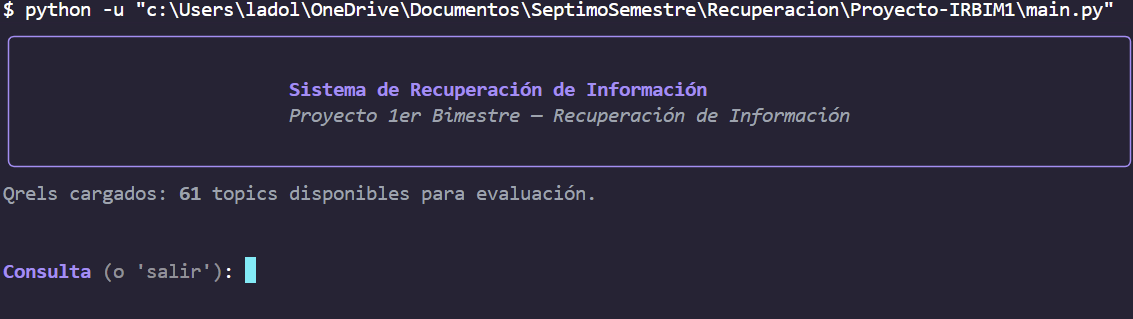
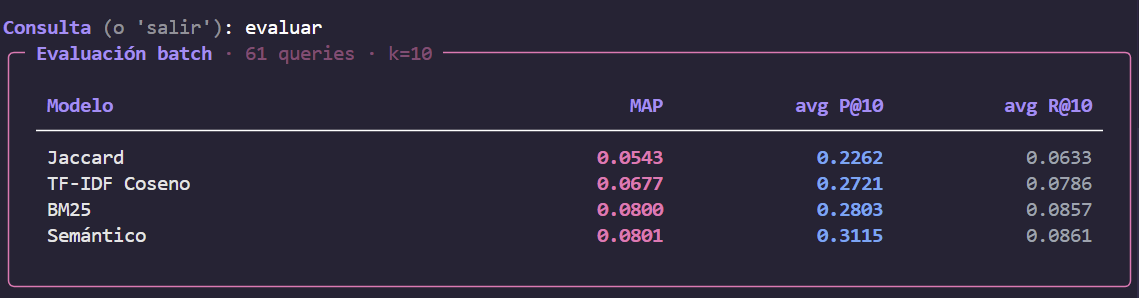
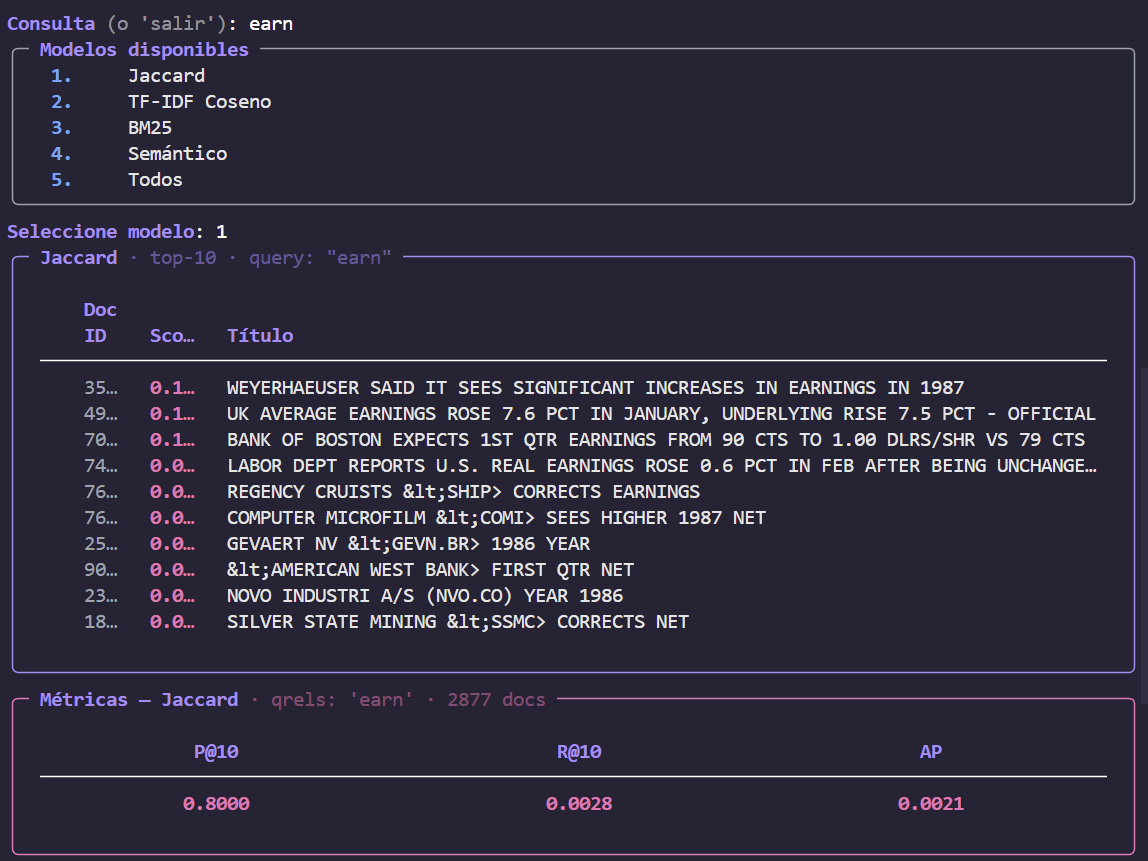
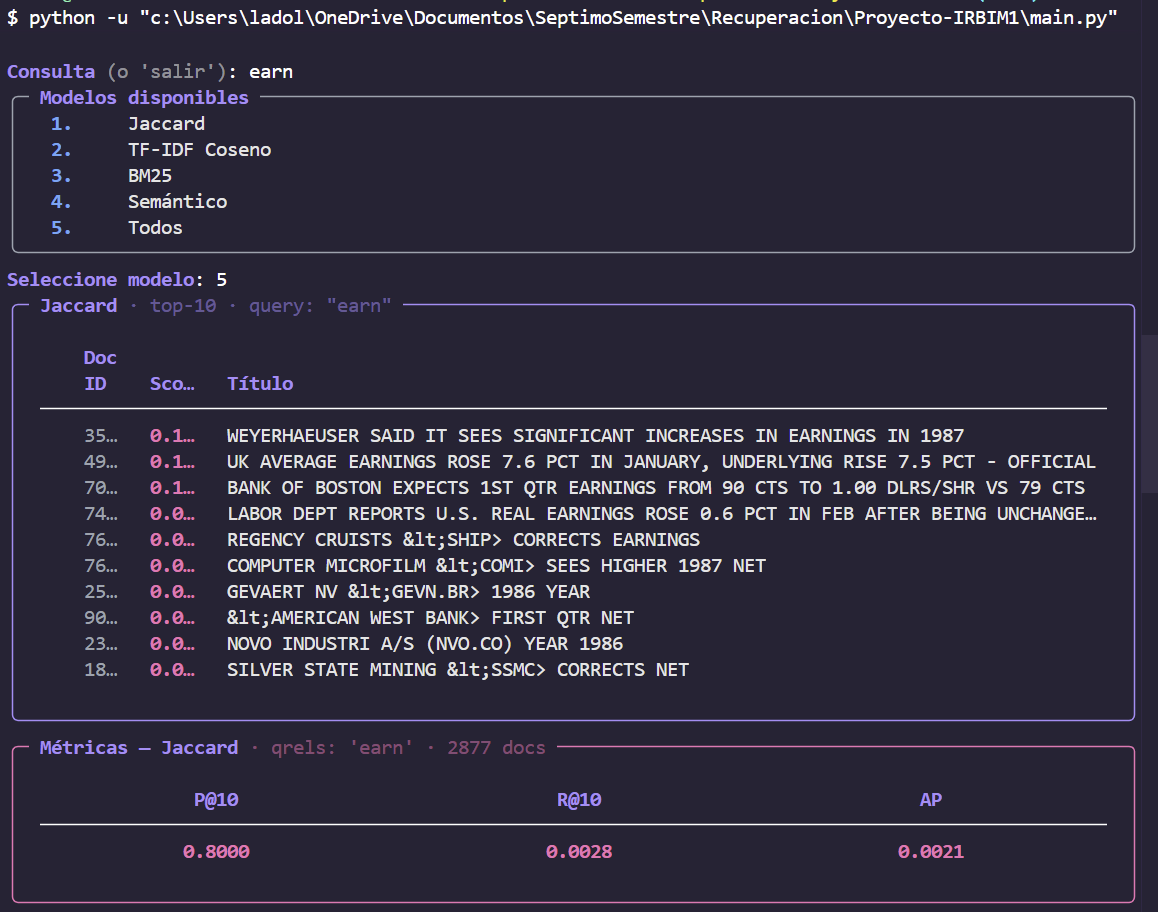
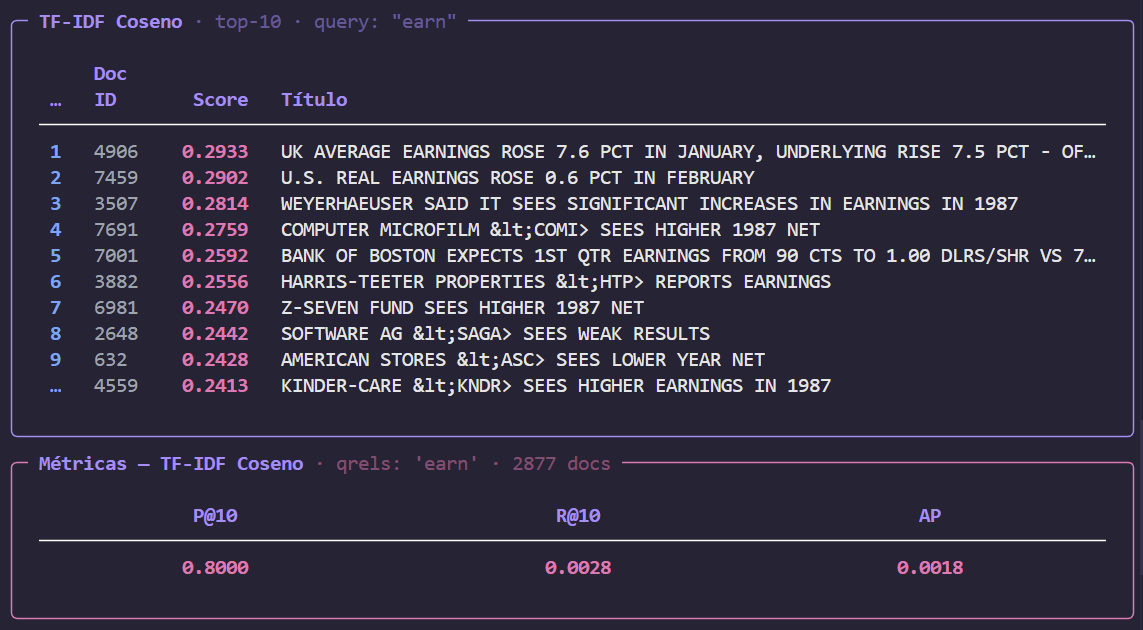
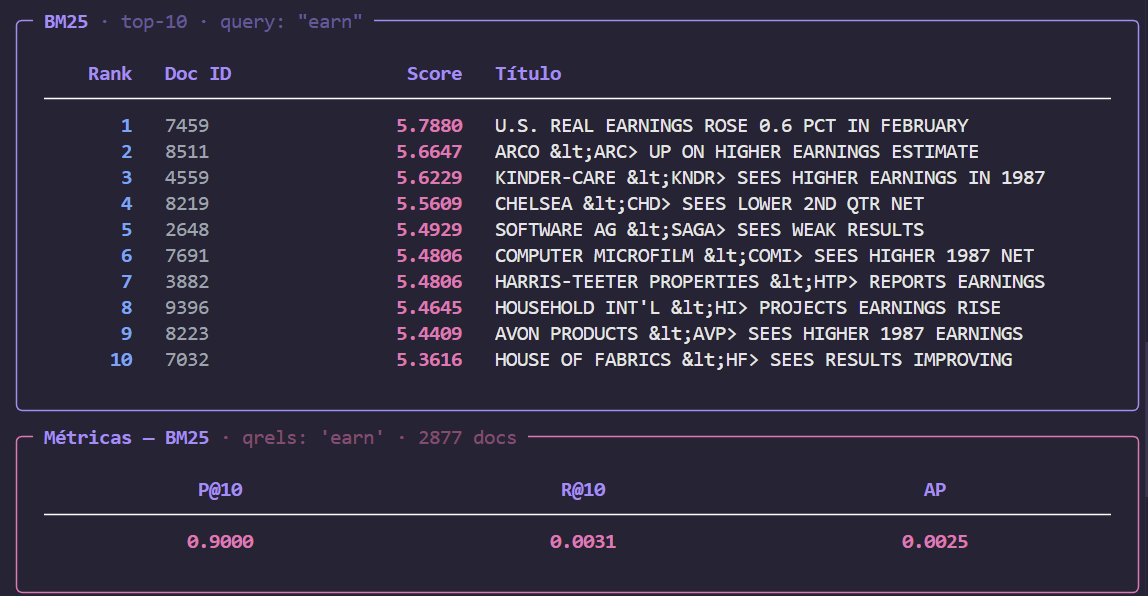
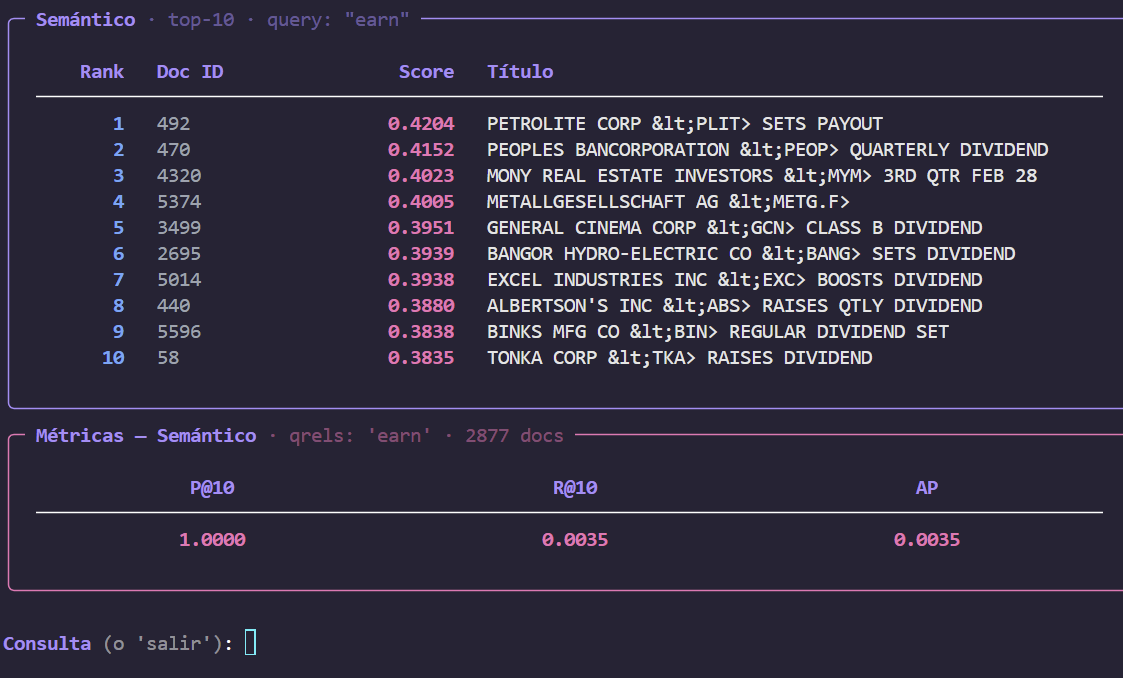
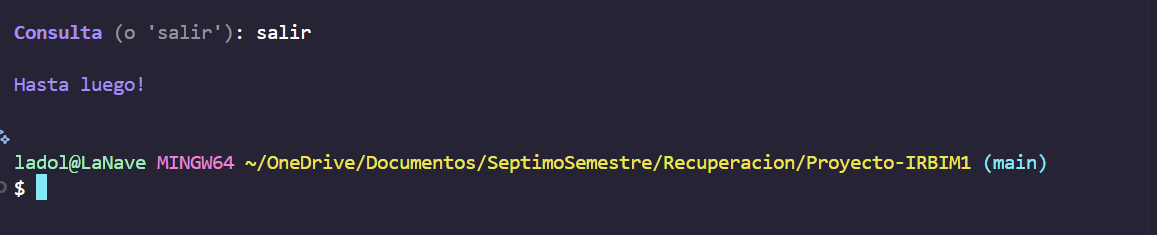